In [1]:
import pyvisa
import numpy as np
import time
import matplotlib.pyplot as plt

In [7]:
class TDS6604Controller:
    def __init__(self, gpib_address='GPIB0::2::INSTR'):
        """Connect to scope"""
        self.rm = pyvisa.ResourceManager()
        self.scope = self.rm.open_resource(gpib_address)
        self.scope.timeout = 30000

        idn = self.scope.query('*IDN?')
        print(f"Connected to: {idn.strip()}")
        self.scope.write('*CLS')

    def get_current_settings(self, channel=1):
        """Display all current scope settings"""
        print(f"\n{'='*60}")
        print(f"CURRENT SCOPE SETTINGS")
        print(f"{'='*60}")

        print(f"\nChannel {channel}:")
        scale = self.scope.query(f'CH{channel}:SCALE?').strip()
        print(f"  Scale:     {scale} V/div")

        position = self.scope.query(f'CH{channel}:POSITION?').strip()
        print(f"  Position:  {position} div")

        coupling = self.scope.query(f'CH{channel}:COUPLING?').strip()
        print(f"  Coupling:  {coupling}")

        print(f"\nHorizontal:")
        h_scale = self.scope.query('HORIZONTAL:MAIN:SCALE?').strip()
        h_scale_float = float(h_scale)
        print(f"  Scale:         {h_scale} s/div ({h_scale_float*1e9:.3f} ns/div)")

        record_length = self.scope.query('HORIZONTAL:RECORDLENGTH?').strip()
        print(f"  Record Length: {record_length} points")

        print(f"\nAcquisition:")
        acq_mode = self.scope.query('ACQUIRE:MODE?').strip()
        print(f"  Mode:       {acq_mode}")

        acq_state = self.scope.query('ACQUIRE:STATE?').strip()
        state_str = "Running" if acq_state == '1' else "Stopped"
        print(f"  State:      {acq_state} ({state_str})")

        print(f"\n{'='*60}\n")

    def setup_acquisition(self, channel=1, vertical_scale=0.5,
                         vertical_position=0, horizontal_scale=100e-9,
                         record_length=10000):
        """Setup oscilloscope for acquisition"""
        print(f"\n{'='*60}")
        print(f"CONFIGURING SCOPE")
        print(f"{'='*60}")

        print(f"\n1. Setting up Channel {channel}...")
        self.scope.write(f'SELECT:CH{channel} ON')
        self.scope.write(f'CH{channel}:SCALE {vertical_scale}')
        self.scope.write(f'CH{channel}:POSITION {vertical_position}')
        self.scope.write(f'CH{channel}:COUPLING DC')

        actual_scale = float(self.scope.query(f'CH{channel}:SCALE?').strip())
        print(f"   Scale: {actual_scale} V/div")
        print(f"   Channel configured")

        print(f"\n2. Setting up Timebase...")
        self.scope.write(f'HORIZONTAL:MAIN:SCALE {horizontal_scale}')

        actual_h_scale = float(self.scope.query('HORIZONTAL:MAIN:SCALE?').strip())
        print(f"   Requested: {horizontal_scale*1e9:.3f} ns/div")
        print(f"   Actual:    {actual_h_scale*1e9:.3f} ns/div")
        print(f"   Timebase set")

        print(f"\n3. Setting up Record Length...")
        self.scope.write(f'HORIZONTAL:RECORDLENGTH {record_length}')
        actual_length = int(float(self.scope.query('HORIZONTAL:RECORDLENGTH?').strip()))
        print(f"   Set to: {actual_length} points")

        print(f"\n4. Setting up Acquisition Mode...")
        self.scope.write('ACQUIRE:MODE SAMPLE')
        self.scope.write('ACQUIRE:STOPAFTER SEQUENCE')
        print(f"   ✓ Single-sequence mode enabled")

        print(f"\n{'='*60}")
        print(f"SETUP COMPLETE")
        print(f"{'='*60}\n")

    def setup_trigger(self, source='CH1', level=1.65, edge='RISE', coupling='DC'):
        """Setup trigger with working verification"""
        print(f"\n{'='*60}")
        print(f"CONFIGURING TRIGGER")
        print(f"{'='*60}")

        print(f"\nSetting trigger parameters...")

        self.scope.write('TRIGGER:A:TYPE EDGE')
        self.scope.write(f'TRIGGER:A:EDGE:SOURCE {source}')
        self.scope.write(f'TRIGGER:A:EDGE:SLOPE {edge}')
        self.scope.write(f'TRIGGER:A:EDGE:COUPLING {coupling}')
        self.scope.write(f'TRIGGER:A:LEVEL {level}')
        self.scope.write('TRIGGER:A:MODE NORMAL')

        # Set trigger position at LEFT edge to capture full pattern
        self.scope.write('HORIZONTAL:MAIN:POSITION 0')

        # time.sleep(0.1)
        # print(f"\nVerifying settings...")
        # try:
        #     actual_source = self.scope.query('TRIGGER:A:EDGE:SOURCE?').strip()
        #     actual_slope = self.scope.query('TRIGGER:A:EDGE:SLOPE?').strip()
        #     actual_coupling = self.scope.query('TRIGGER:A:EDGE:COUPLING?').strip()
        #     actual_level = float(self.scope.query('TRIGGER:A:LEVEL?').strip())
        #     actual_mode = self.scope.query('TRIGGER:A:MODE?').strip()
        #
        #     print(f"  Source:   {actual_source}")
        #     print(f"  Slope:    {actual_slope}")
        #     print(f"  Coupling: {actual_coupling}")
        #     print(f"  Level:    {actual_level:.3f} V")
        #     print(f"  Mode:     {actual_mode}")
        #     print(f"\n  ✓ All settings verified")
        # except Exception as e:
        #     print(f"  Could not verify all settings: {e}")

        print(f"\n✓ Trigger configured")
        print(f"{'='*60}\n")


    def get_trigger_settings(self):
        """Query current trigger settings - uses verified working commands"""
        print(f"\n{'='*60}")
        print(f"CURRENT TRIGGER SETTINGS")
        print(f"{'='*60}\n")

        settings = {}

        try:
            settings['type'] = self.scope.query('TRIGGER:A:TYPE?').strip()
            print(f"  Type:              {settings['type']}")
        except:
            print(f"  Type:              (query failed)")

        try:
            settings['mode'] = self.scope.query('TRIGGER:A:MODE?').strip()
            print(f"  Mode:              {settings['mode']}")
        except:
            print(f"  Mode:              (query failed)")

        try:
            settings['source'] = self.scope.query('TRIGGER:A:EDGE:SOURCE?').strip()
            print(f"  Source:            {settings['source']}")
        except:
            print(f"  Source:            (query failed)")

        try:
            settings['slope'] = self.scope.query('TRIGGER:A:EDGE:SLOPE?').strip()
            print(f"  Slope:             {settings['slope']}")
        except:
            print(f"  Slope:             (query failed)")

        try:
            settings['coupling'] = self.scope.query('TRIGGER:A:EDGE:COUPLING?').strip()
            print(f"  Coupling:          {settings['coupling']}")
        except:
            print(f"  Coupling:          (query failed)")

        try:
            # This is the format that works!
            level = self.scope.query('TRIGGER:A:LEVEL?').strip()
            level_volts = float(level)
            settings['level'] = level_volts
            print(f"  Level:             {level_volts:.3f} V")
        except:
            print(f"  Level:             (query failed)")

        try:
            holdoff = self.scope.query('TRIGGER:A:HOLDOFF:TIME?').strip()
            settings['holdoff'] = float(holdoff)
            print(f"  Holdoff:           {holdoff} s ({float(holdoff)*1e9:.1f} ns)")
        except:
            print(f"  Holdoff:           (query failed)")

        try:
            h_pos = self.scope.query('HORIZONTAL:TRIGGER:POSITION?').strip()
            settings['h_position'] = float(h_pos)
            print(f"  Horiz Position:    {h_pos} %")
        except:
            print(f"  Horiz Position:    (query failed)")

        print(f"\n{'='*60}\n")

        return settings

    def setup_for_pulse(self, channel=1, pulse_voltage=1.0, pulse_width_ns=100):
        """Setup scope to capture a single pulse"""
        print(f"\n{'='*60}")
        print(f"CONFIGURING OSCILLOSCOPE")
        print(f"{'='*60}\n")

        # 1. Channel setup
        print("1. Channel setup...")
        self.scope.write(f'SELECT:CH{channel} ON')

        # Vertical scale: set to see full pulse range
        v_scale = pulse_voltage / 3  # Pulse will occupy ~3 divisions
        self.scope.write(f'CH{channel}:SCALE {v_scale}')
        self.scope.write(f'CH{channel}:POSITION -2')  # Shift down to see 0V baseline
        self.scope.write(f'CH{channel}:COUPLING DC')
        print(f"   Vertical: {v_scale} V/div, position: -2 div")

        # 2. Horizontal setup
        print("\n2. Horizontal setup...")
        # Show pulse with context before and after
        display_time = pulse_width_ns * 20e-9  # 20x pulse width for good view
        h_scale = display_time / 10
        self.scope.write(f'HORIZONTAL:MAIN:SCALE {h_scale}')

        # Trigger at left edge to capture full pulse
        self.scope.write('HORIZONTAL:MAIN:POSITION 10')  # 10% from left

        actual_h_scale = float(self.scope.query('HORIZONTAL:MAIN:SCALE?').strip())
        print(f"   Timebase: {actual_h_scale*1e9:.1f} ns/div")
        print(f"   Total window: {actual_h_scale*10*1e6:.2f} μs")

        # 3. Record length
        print("\n3. Record length...")
        record_length = 10000
        self.scope.write(f'HORIZONTAL:RECORDLENGTH {record_length}')
        actual_length = int(float(self.scope.query('HORIZONTAL:RECORDLENGTH?').strip()))
        print(f"   Record length: {actual_length} points")

        # 4. Acquisition mode
        print("\n4. Acquisition mode...")
        self.scope.write('ACQUIRE:MODE SAMPLE')
        self.scope.write('ACQUIRE:STOPAFTER SEQUENCE')
        print("   Mode: Single sequence")

        print(f"\n✓ Oscilloscope configured")
        print(f"{'='*60}\n")

    def arm_acquisition(self):
        """Arm scope for single acquisition"""
        print(f"Arming scope (waiting for trigger)...")
        self.scope.write('ACQUIRE:STATE RUN')
        time.sleep(0.1)  # Let scope arm

    def update_display(self):
        """Force display to show captured waveform"""
        print("Updating display...")
        # Some options to try:
        self.scope.write('DISPLAY:PERSISTENCE OFF')
        self.scope.write('DISPLAY:STYLE:DOTSONLY OFF')  # Show interpolated lines
        # Force a screen refresh
        time.sleep(0.1)
        print("✓ Display updated\n")

    def wait_for_acquisition(self, timeout=10):
        """Wait for acquisition to complete"""
        print("Waiting for acquisition to complete...")
        start_time = time.time()
        while True:
            state = int(self.scope.query('ACQUIRE:STATE?').strip())
            if state == 0:  # Stopped = acquisition complete
                print("✓ Acquisition complete!\n")
                # Update display after acquisition
                self.update_display()
                return True
            if time.time() - start_time > timeout:
                print("✗ Acquisition timeout!\n")
                return False
            time.sleep(0.1)


    def capture_with_force_trigger(self):
        """Capture using software force trigger"""
        print("\n" + "="*70)
        print("CAPTURE WITH SOFTWARE FORCE TRIGGER")
        print("="*70)
        print("\nThis will capture whatever is on CH1 right now")
        print("(Even if just noise - that's fine for testing)\n")

        input("Press Enter to capture...")

        print("\nStarting acquisition...")

        # Stop any current acquisition
        self.scope.write('ACQUIRE:STATE OFF')
        time.sleep(0.1)

        # Start single sequence acquisition
        self.scope.write('ACQUIRE:STOPAFTER SEQUENCE')
        self.scope.write('ACQUIRE:STATE RUN')
        time.sleep(0.2)

        print("   Scope armed")

        # Force trigger via software
        print("   Forcing trigger via software...")
        self.scope.write('TRIGGER FORCE')

        # Wait for acquisition to complete
        time.sleep(0.5)

        # Check state
        max_wait = 5
        start = time.time()

        while time.time() - start < max_wait:
            state = int(self.scope.query('ACQUIRE:STATE?').strip())
            if state == 0:
                print("   ✓ Acquisition complete!")
                return True
            time.sleep(0.1)

        # Even if state isn't 0, data might be available
        print("Timeout waiting for state, but trying to get data anyway...")
        return True

    def get_waveform_data(self, channel=1):
        """Retrieve waveform data"""
        print(f"{'='*60}")
        print(f"RETRIEVING WAVEFORM DATA")
        print(f"{'='*60}\n")

        try:
            # Configure data transfer
            print("1. Configuring data transfer...")
            self.scope.write(f'DATA:SOURCE CH{channel}')
            self.scope.write('DATA:ENCDG RIBINARY')
            self.scope.write('DATA:WIDTH 2')
            self.scope.write('DATA:START 1')

            # Get record length
            record_length = int(float(self.scope.query('HORIZONTAL:RECORDLENGTH?').strip()))
            self.scope.write(f'DATA:STOP {record_length}')
            print(f"   Record length: {record_length} points")

            # Get scaling parameters
            print("\n2. Getting scaling parameters...")
            x_incr = float(self.scope.query('WFMPRE:XINCR?').strip())
            x_zero = float(self.scope.query('WFMPRE:XZERO?').strip())
            y_mult = float(self.scope.query('WFMPRE:YMULT?').strip())
            y_zero = float(self.scope.query('WFMPRE:YZERO?').strip())
            y_off = float(self.scope.query('WFMPRE:YOFF?').strip())
            print(f"   X increment: {x_incr*1e9:.3f} ns/point")

            # Request waveform
            print("\n3. Requesting waveform...")
            self.scope.write('CURVE?')

            print("4. Reading binary data...")
            raw_data = self.scope.read_raw()
            print(f"   Received {len(raw_data)} bytes")

            # Parse binary data
            print("\n5. Parsing...")
            header_len = 2 + int(chr(raw_data[1]))
            byte_count = int(raw_data[2:header_len].decode('ascii'))
            data_bytes = raw_data[header_len:header_len + byte_count]

            # Convert to voltage
            print("\n6. Converting to voltage...")
            voltage_raw = np.frombuffer(data_bytes, dtype=np.dtype('>i2'))
            voltage = (voltage_raw - y_off) * y_mult + y_zero

            # Time array
            time_array = np.arange(len(voltage)) * x_incr + x_zero

            # # Stats
            # print(f"\n7. Waveform stats:")
            # print(f"   Points: {len(voltage)}")
            # print(f"   Time: {time_array[0]*1e6:.3f} to {time_array[-1]*1e6:.3f} μs")
            # print(f"   Voltage: {voltage.min():.3f} to {voltage.max():.3f} V")
            # print(f"   Mean: {voltage.mean():.3f} V")

            print(f"\n✓ Waveform retrieved successfully")
            print(f"{'='*60}\n")

            return {
                'time': time_array,
                'voltage': voltage,
                'points': len(voltage)
            }

        except Exception as e:
            print(f"\n✗ Error: {e}")
            import traceback
            traceback.print_exc()
            return None


    def save_waveform(self, waveform, filename='waveform.csv'):
        """Save waveform to CSV with metadata header"""
        if waveform is None:
            return

        print(f"\nSaving to {filename}...")

        # Gather metadata from scope
        try:
            metadata = self._get_scope_metadata()
        except:
            metadata = {}

        # Create header with metadata
        header_lines = []
        header_lines.append("TDS 6604 Waveform Data")
        header_lines.append(f"Captured: {time.strftime('%Y-%m-%d %H:%M:%S')}")
        header_lines.append("")

        # Add metadata
        header_lines.append("SCOPE SETTINGS:")
        for key, value in metadata.items():
            header_lines.append(f"  {key}: {value}")

        header_lines.append("")
        header_lines.append("DATA:")
        header_lines.append("Time (s), Voltage (V)")

        # Combine into single header string
        header = '\n'.join(header_lines)

        # Save data
        data = np.column_stack((waveform['time'], waveform['voltage']))
        np.savetxt(filename, data, delimiter=',', header=header, comments='# ')

        print(f"✓ Saved {len(waveform['voltage'])} points with metadata")

    def _get_scope_metadata(self):
        """Gather scope configuration metadata"""
        metadata = {}

        try:
            # Identification
            metadata['Instrument'] = self.scope.query('*IDN?').strip()

            # Channel settings
            ch_scale = self.scope.query('CH1:SCALE?').strip()
            ch_position = self.scope.query('CH1:POSITION?').strip()
            ch_coupling = self.scope.query('CH1:COUPLING?').strip()
            ch_bw = self.scope.query('CH1:BANDWIDTH?').strip()

            metadata['CH1 Scale'] = f"{float(ch_scale)} V/div"
            metadata['CH1 Position'] = f"{float(ch_position)} div"
            metadata['CH1 Coupling'] = ch_coupling
            metadata['CH1 Bandwidth'] = ch_bw

            # Horizontal settings
            h_scale = self.scope.query('HORIZONTAL:MAIN:SCALE?').strip()
            h_position = self.scope.query('HORIZONTAL:MAIN:POSITION?').strip()
            record_length = self.scope.query('HORIZONTAL:RECORDLENGTH?').strip()

            metadata['Timebase'] = f"{float(h_scale)*1e9:.3f} ns/div"
            metadata['Horizontal Position'] = f"{float(h_position)} %"
            metadata['Record Length'] = f"{int(float(record_length))} points"

            # Acquisition settings
            acq_mode = self.scope.query('ACQUIRE:MODE?').strip()
            metadata['Acquisition Mode'] = acq_mode

            # Trigger settings
            try:
                trig_source = self.scope.query('TRIGGER:A:EDGE:SOURCE?').strip()
                trig_slope = self.scope.query('TRIGGER:A:EDGE:SLOPE?').strip()
                trig_level = self.scope.query('TRIGGER:A:LEVEL?').strip()
                trig_mode = self.scope.query('TRIGGER:A:MODE?').strip()

                metadata['Trigger Source'] = trig_source
                metadata['Trigger Slope'] = trig_slope
                metadata['Trigger Level'] = f"{float(trig_level)} V"
                metadata['Trigger Mode'] = trig_mode
            except:
                pass

            # Waveform parameters
            x_incr = self.scope.query('WFMPRE:XINCR?').strip()
            y_mult = self.scope.query('WFMPRE:YMULT?').strip()

            metadata['Sample Interval'] = f"{float(x_incr)*1e9:.6f} ns"
            metadata['Voltage Resolution'] = f"{float(y_mult)*1e6:.6f} uV/count"

        except Exception as e:
            print(f"  (Warning: Could not retrieve all metadata: {e})")

        return metadata

    def plot_waveform(self, waveform, filename='waveform_plot.png'):
        """Plot waveform"""
        if waveform is None:
            return

        print("\n\Plotting...")

        fig, ax = plt.subplots(figsize=(12, 6))
        ax.plot(waveform['time'] * 1e6, waveform['voltage'], 'b-', linewidth=0.5)
        ax.set_xlabel('Time (μs)')
        ax.set_ylabel('Voltage (V)')
        ax.set_title(f'TDS 6604 Waveform ({waveform["points"]} points)')
        ax.grid(True)

        plt.tight_layout()
        plt.savefig(filename, dpi=150)
        print("Saved to waveform_plot.png")

        try:
            plt.show()
        except:
            print("  (Display not available - saved to file)")


    def close(self):
        """Close connection"""
        self.scope.close()
        self.rm.close()
        print("\n Connection closed")

    def test_with_force_trigger(self, channel=1):
        """Test acquisition using software force trigger"""
        print("\n" + "="*60)
        print("TEST MODE: FORCE TRIGGER")
        print("="*60 + "\n")

        print("This will capture whatever is currently on the input")
        print("(Even if just noise - useful for testing)\n")

        # Stop any running acquisition
        self.scope.write('ACQUIRE:STATE OFF')
        time.sleep(0.2)

        # Make sure channel is displayed
        self.scope.write(f'SELECT:CH{channel} ON')
        self.scope.write('DISPLAY:PERSISTENCE OFF')

        # Arm for single acquisition
        self.scope.write('ACQUIRE:STOPAFTER SEQUENCE')
        self.scope.write('ACQUIRE:STATE RUN')
        time.sleep(0.3)
        print("Scope armed...")

        # Force trigger
        print("Forcing trigger...")
        self.scope.write('TRIGGER FORCE')
        time.sleep(0.5)

        # Wait for completion
        max_wait = 5
        start = time.time()
        while time.time() - start < max_wait:
            state = int(self.scope.query('ACQUIRE:STATE?').strip())
            if state == 0:
                print("✓ Acquisition complete!")
                break
            time.sleep(0.1)

        # Update display
        self.update_display()

        print("\nCheck the scope display - you should see the waveform")
        print("(It will be stopped/frozen)")

        return True

In [3]:
class BNC765Controller:
    def __init__(self, ip_address='169.254.125.69'):
        """Connect to BNC 765 Pulse Generator"""
        self.ip = ip_address
        self.rm = pyvisa.ResourceManager()
        self.pulser = self.rm.open_resource(f'TCPIP::{self.ip}::INSTR')
        self.pulser.timeout = 10000
        idn = self.pulser.query('*IDN?')
        print(f"Connected to Pulser: {idn.strip()}")

    def setup_single_pulse(self, channel=1, width_ns=100, voltage=1.0,
                          trig_out_voltage=3.3):
        """
        Configure for single pulse burst mode

        Parameters:
        -----------
        channel : int
            Output channel (1-4)
        width_ns : float
            Pulse width in nanoseconds
        voltage : float
            Pulse amplitude in volts (0 to voltage)
        trig_out_voltage : float
            Trigger output amplitude in volts (minimum 0.9V)
        """
        print(f"\n{'='*60}")
        print(f"CONFIGURING PULSE GENERATOR")
        print(f"{'='*60}\n")

        # Turn off output
        self.pulser.write(f'OUTPUT{channel}:STATE OFF')
        time.sleep(0.1)

        # Setup main pulse output
        print("1. Pulse output settings...")
        self.pulser.write(f'SOURCE{channel}:VOLTAGE:LEVEL {voltage}')
        self.pulser.write(f'SOURCE{channel}:VOLTAGE:OFFSET {voltage/2}')
        self.pulser.write(f'SOURCE{channel}:PULSE:WIDTH {width_ns}E-9')
        self.pulser.write(f'SOURCE{channel}:FREQUENCY 1000000')  # 1 MHz base
        print(f"   Pulse: {width_ns} ns, 0 to {voltage} V")

        # Setup burst mode
        print("\n2. Burst mode settings...")
        self.pulser.write(f'SOURCE{channel}:BURST:NCYCLES 1')
        self.pulser.write('TRIGGER:MODE BURST')
        self.pulser.write('TRIGGER:SOURCE MANUAL')
        print(f"   Single pulse per trigger")

        # Setup trigger output
        print("\n3. Trigger output settings...")
        if trig_out_voltage < 0.9:
            print(f"   Warning: Requested {trig_out_voltage}V, using minimum 0.9V")
            trig_out_voltage = 0.9

        self.pulser.write(f'TRIGGER:OUTPUT:AMPLITUDE {trig_out_voltage}')
        self.pulser.write('TRIGGER:OUTPUT:POLARITY POSITIVE')
        self.pulser.write(f'TRIGGER:OUTPUT:SOURCE OUT{channel}')

        time.sleep(0.2)

        # Verify settings
        try:
            trig_amp = self.pulser.query('TRIGGER:OUTPUT:AMPLITUDE?').strip()
            trig_pol = self.pulser.query('TRIGGER:OUTPUT:POLARITY?').strip()
            trig_src = self.pulser.query('TRIGGER:OUTPUT:SOURCE?').strip()
            print(f"   Trigger Out: {trig_amp} V, {trig_pol}, Source: {trig_src}")
        except:
            print(f"   Trigger Out: {trig_out_voltage} V (verify failed)")

        # Enable output
        self.pulser.write(f'OUTPUT{channel}:STATE ON')
        print(f"\n✓ Pulse generator configured and armed")
        print(f"{'='*60}\n")

    def trigger_pulse(self):
        """Send trigger for single pulse"""
        self.pulser.write('*TRG')
        print("✓ Pulse triggered!")

    def cleanup(self, channel=1):
        """Disable output and return to continuous mode"""
        self.pulser.write(f'OUTPUT{channel}:STATE OFF')
        self.pulser.write('TRIGGER:MODE CONTINUOUS')

    def close(self):
        """Close connection"""
        self.pulser.close()
        print("Pulser connection closed")

In [7]:
# # ============================================================================
# # MAIN PROGRAM
# # ============================================================================
#
# if __name__ == '__main__':
#
#     print("="*70)
#     print("SINGLE-CHANNEL 4-PULSE BURST SYSTEM")
#     print("="*70)
#     print("\nHardware Setup:")
#     print("  BNC 765 CH1 ──> Scope CH1 (direct connection)")
#     print("  Set scope to 50Ω input impedance\n")
#
#     system = SingleChannel4PulseSystem()
#
#     try:
#         # Configure for 4 positive pulses
#         system.setup_4pulse_burst(
#             pulse_width=200e-9,
#             pulse_spacing=500e-9,
#             amplitude=2.0,
#             polarity='positive'  # or 'negative' for negative pulses
#         )
#
#         # Setup scope
#         system.setup_scope(
#             amplitude=2.0,
#             polarity='positive'
#         )
#
#         # Ready to capture
#         print("\n" + "="*70)
#         print("READY TO CAPTURE")
#         print("="*70)
#         print("\nHardware checklist:")
#         print("  ☐ BNC CH1 connected to Scope CH1")
#         print("  ☐ Scope set to 50Ω input (via menu or software)")
#         print("  ☐ Both instruments powered on")
#
#         input("\nPress Enter to capture 4-pulse burst...")
#
#         # Capture
#         waveform = system.capture_burst()
#
#         if waveform:
#             # Save
#             system.save_waveform(waveform, '4pulse_single_channel.csv')
#
#             # Plot
#             plot = input("\nPlot waveform? (y/n): ").strip().lower()
#             if plot == 'y':
#                 import matplotlib.pyplot

SyntaxError: incomplete input (1228715942.py, line 52)


SINGLE PULSE GENERATION AND CAPTURE

Configuration:
  Pulse: 100 ns, 1.0 V
  Trigger output: 1.0 V

Test options:
  1. Full test with pulse generator (requires hardware connections)
  2. Scope-only test with force trigger (no pulser needed)

SCOPE-ONLY TEST MODE

Connected to: TEKTRONIX,TDS6604,B010466,CF:91.1CT FV:2.5.3

CONFIGURING OSCILLOSCOPE

1. Channel setup...
   Vertical: 0.3333333333333333 V/div, position: -2 div

2. Horizontal setup...
   Timebase: 200.0 ns/div
   Total window: 2.00 μs

3. Record length...
   Record length: 10000 points

4. Acquisition mode...
   Mode: Single sequence

✓ Oscilloscope configured


TEST MODE: FORCE TRIGGER

This will capture whatever is currently on the input
(Even if just noise - useful for testing)

Scope armed...
Forcing trigger...
Updating display...
✓ Display updated


Check the scope display - you should see the waveform
(It will be stopped/frozen)

Attempting to retrieve waveform data...
RETRIEVING WAVEFORM DATA

1. Configuring data tra

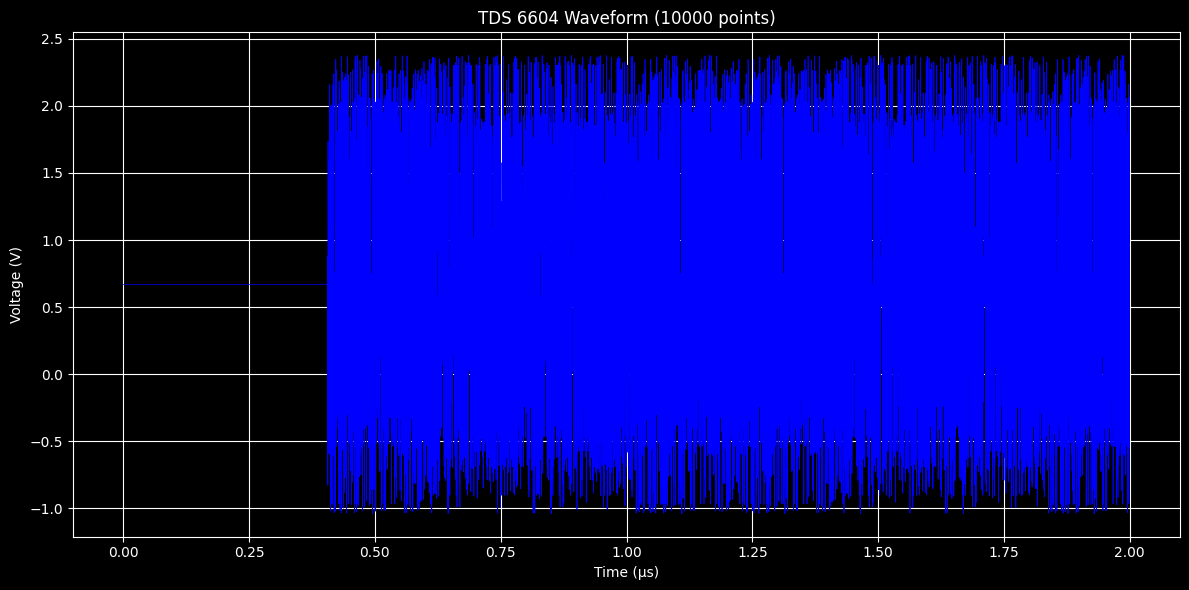

CAPTURE COMPLETE

Captured 10000 points
Voltage range: -1.042 to 2.378 V
Mean: 0.651 V

CLEANUP


 Connection closed

✓ Program complete



In [8]:
def main():
    """Main program to generate and capture a single pulse"""

    print("\n" + "="*60)
    print("SINGLE PULSE GENERATION AND CAPTURE")
    print("="*60 + "\n")

    # Configuration
    PULSER_IP = '169.254.125.69'
    SCOPE_GPIB = 'GPIB0::2::INSTR'

    PULSE_CHANNEL = 1
    PULSE_WIDTH_NS = 100
    PULSE_VOLTAGE = 1.0
    TRIGGER_VOLTAGE = 1.0

    print("Configuration:")
    print(f"  Pulse: {PULSE_WIDTH_NS} ns, {PULSE_VOLTAGE} V")
    print(f"  Trigger output: {TRIGGER_VOLTAGE} V\n")

    # Test mode selection
    print("Test options:")
    print("  1. Full test with pulse generator (requires hardware connections)")
    print("  2. Scope-only test with force trigger (no pulser needed)")
    choice = input("\nEnter choice (1 or 2): ")

    try:
        if choice == '2':
            # ========== SCOPE-ONLY TEST MODE ==========
            print("\n" + "="*60)
            print("SCOPE-ONLY TEST MODE")
            print("="*60 + "\n")

            scope = TDS6604Controller(SCOPE_GPIB)

            # Setup scope
            scope.setup_for_pulse(
                channel=1,
                pulse_voltage=PULSE_VOLTAGE,
                pulse_width_ns=PULSE_WIDTH_NS
            )

            # Force trigger test
            input("Press Enter to force trigger and capture...")
            scope.test_with_force_trigger(channel=1)

            # Try to get waveform data
            print("\nAttempting to retrieve waveform data...")
            waveform = scope.get_waveform_data(channel=1)

            if waveform is not None:
                # Plot
                scope.plot_waveform(waveform, filename='force_trigger_test.png')

                print("="*60)
                print("CAPTURE COMPLETE")
                print("="*60)
                print(f"\nCaptured {waveform['points']} points")
                print(f"Voltage range: {waveform['voltage'].min():.3f} to {waveform['voltage'].max():.3f} V")
                print(f"Mean: {waveform['voltage'].mean():.3f} V")
            else:
                print("\n✗ Failed to retrieve waveform data")

            # Cleanup
            print("\n" + "="*60)
            print("CLEANUP")
            print("="*60 + "\n")
            scope.close()

        else:
            # ========== FULL TEST WITH PULSER ==========
            print("\n" + "="*60)
            print("FULL TEST WITH PULSE GENERATOR")
            print("="*60 + "\n")

            print("Hardware connections required:")
            print(f"  1. Pulser CH{PULSE_CHANNEL} → Scope CH1")
            print(f"  2. Pulser TRIG OUT → Scope EXT TRIG")
            print()

            input("Press Enter when connections are ready...")

            # Connect to instruments
            print("\n" + "="*60)
            print("CONNECTING TO INSTRUMENTS")
            print("="*60 + "\n")

            pulser = BNC765Controller(PULSER_IP)
            scope = TDS6604Controller(SCOPE_GPIB)

            # Setup pulser
            pulser.setup_single_pulse(
                channel=PULSE_CHANNEL,
                width_ns=PULSE_WIDTH_NS,
                voltage=PULSE_VOLTAGE,
                trig_out_voltage=TRIGGER_VOLTAGE
            )

            # Setup scope
            scope.setup_for_pulse(
                channel=1,
                pulse_voltage=PULSE_VOLTAGE,
                pulse_width_ns=PULSE_WIDTH_NS
            )

            # Setup scope trigger
            scope.setup_trigger_external(level=TRIGGER_VOLTAGE/2)

            # Arm scope
            scope.arm_acquisition()

            # Generate pulse
            print("="*60)
            print("GENERATING PULSE")
            print("="*60 + "\n")

            input("Press Enter to trigger pulse...")

            pulser.trigger_pulse()

            # Wait for scope to capture
            if scope.wait_for_acquisition(timeout=5):
                # Get waveform
                waveform = scope.get_waveform_data(channel=1)

                if waveform is not None:
                    # Plot
                    scope.plot_waveform(waveform)

                    print("="*60)
                    print("SUCCESS!")
                    print("="*60)
                    print(f"\nCaptured {waveform['points']} points")
                    print(f"Pulse peak: {waveform['voltage'].max():.3f} V")
                    print(f"Baseline: {waveform['voltage'].min():.3f} V")
            else:
                print("\n✗ Failed to capture waveform")

            # Cleanup
            print("\n" + "="*60)
            print("CLEANUP")
            print("="*60 + "\n")

            pulser.cleanup(PULSE_CHANNEL)
            pulser.close()
            scope.close()

        print("\n✓ Program complete\n")

    except Exception as e:
        print(f"\n✗ Error: {e}")
        import traceback
        traceback.print_exc()


if __name__ == "__main__":
    main()

In [10]:
import pyvisa
import time

def test_scope_display():
    """Simple test to verify scope display is working"""

    print("\n" + "="*60)
    print("SCOPE DISPLAY TEST")
    print("="*60 + "\n")

    # Connect
    rm = pyvisa.ResourceManager()
    scope = rm.open_resource('GPIB0::2::INSTR')
    scope.timeout = 10000

    idn = scope.query('*IDN?')
    print(f"Connected to: {idn.strip()}\n")

    # Clear and reset
    print("1. Resetting scope...")
    scope.write('*RST')
    time.sleep(2)
    print("   ✓ Reset complete\n")

    # Turn on channel 1
    print("2. Enabling Channel 1...")
    scope.write('SELECT:CH1 ON')
    scope.write('CH1:COUPLING DC')
    scope.write('CH1:SCALE 0.5')
    scope.write('CH1:POSITION 0')
    print("   ✓ Channel 1 configured\n")

    # Set timebase
    print("3. Setting timebase...")
    scope.write('HORIZONTAL:MAIN:SCALE 100E-9')  # 100 ns/div
    print("   ✓ Timebase set to 100 ns/div\n")

    # Set to continuous acquisition
    print("4. Starting continuous acquisition...")
    scope.write('ACQUIRE:STOPAFTER RUNSTOP')  # Continuous
    scope.write('ACQUIRE:STATE RUN')
    time.sleep(1)
    print("   ✓ Scope running\n")

    print("="*60)
    print("CHECK SCOPE DISPLAY NOW")
    print("="*60)
    print("\nYou should see:")
    print("  - CH1 trace (probably noise if no signal connected)")
    print("  - Running/acquiring indicator")
    print("  - Grid with timebase 100 ns/div")
    print("  - Vertical scale 0.5 V/div")

    input("\nPress Enter when you've checked the display...")

    # Now try single sequence mode
    print("\n5. Testing SINGLE SEQUENCE mode...")
    scope.write('ACQUIRE:STATE STOP')
    time.sleep(0.5)

    scope.write('ACQUIRE:STOPAFTER SEQUENCE')
    scope.write('ACQUIRE:STATE RUN')
    print("   Scope armed for single acquisition...")
    time.sleep(0.5)

    print("   Forcing trigger...")
    scope.write('TRIGGER FORCE')
    time.sleep(1)

    # Check acquisition state
    state = scope.query('ACQUIRE:STATE?').strip()
    num_acq = scope.query('ACQUIRE:NUMACQ?').strip()

    print(f"\n   Acquisition state: {state}")
    print(f"   Number of acquisitions: {num_acq}")

    print("\n" + "="*60)
    print("CHECK SCOPE DISPLAY AGAIN")
    print("="*60)
    print("\nAfter single sequence + force trigger, do you see:")
    print("  - A frozen waveform?")
    print("  - 'STOP' indicator?")
    print("  - Anything at all?")

    response = input("\nDo you see a waveform? (y/n): ")

    if response.lower() == 'y':
        print("\n✓ Display is working in single sequence mode!")
    else:
        print("\n✗ Display not showing waveform.")
        print("\nTrying alternate approach...")

        # Try going back to run/stop mode to refresh
        scope.write('ACQUIRE:STOPAFTER RUNSTOP')
        scope.write('ACQUIRE:STATE RUN')
        time.sleep(0.5)
        scope.write('ACQUIRE:STATE STOP')

        print("\nChecked display after RUN/STOP toggle?")
        input("Press Enter to continue...")

    # Cleanup
    print("\n6. Returning to run mode...")
    scope.write('ACQUIRE:STOPAFTER RUNSTOP')
    scope.write('ACQUIRE:STATE RUN')

    scope.close()
    rm.close()

    print("\n✓ Test complete\n")


if __name__ == "__main__":
    test_scope_display()


SCOPE DISPLAY TEST

Connected to: TEKTRONIX,TDS6604,B010466,CF:91.1CT FV:2.5.3

1. Resetting scope...
   ✓ Reset complete

2. Enabling Channel 1...
   ✓ Channel 1 configured

3. Setting timebase...
   ✓ Timebase set to 100 ns/div

4. Starting continuous acquisition...
   ✓ Scope running

CHECK SCOPE DISPLAY NOW

You should see:
  - CH1 trace (probably noise if no signal connected)
  - Running/acquiring indicator
  - Grid with timebase 100 ns/div
  - Vertical scale 0.5 V/div

5. Testing SINGLE SEQUENCE mode...
   Scope armed for single acquisition...
   Forcing trigger...

   Acquisition state: 0
   Number of acquisitions: 1

CHECK SCOPE DISPLAY AGAIN

After single sequence + force trigger, do you see:
  - A frozen waveform?
  - 'STOP' indicator?
  - Anything at all?

✓ Display is working in single sequence mode!

6. Returning to run mode...

✓ Test complete



In [13]:
import pyvisa
import time

def find_run_command():
    """Find the command to start/run the pulser"""

    print("\n" + "="*60)
    print("FINDING PULSER RUN COMMAND")
    print("="*60 + "\n")

    # Connect to pulser
    rm = pyvisa.ResourceManager()
    pulser = rm.open_resource('TCPIP::169.254.125.69::INSTR')
    pulser.timeout = 10000

    print(f"Connected: {pulser.query('*IDN?').strip()}\n")

    # Setup a simple output
    print("Setting up CH1 with 1V, 100ns pulses at 10 kHz...")
    pulser.write('OUTPUT1:STATE OFF')
    time.sleep(0.1)

    pulser.write('SOURCE1:VOLTAGE:LEVEL 1.0')
    pulser.write('SOURCE1:VOLTAGE:OFFSET 0.5')
    pulser.write('SOURCE1:PULSE:WIDTH 100E-9')
    pulser.write('SOURCE1:FREQUENCY 10000')
    pulser.write('TRIGGER:MODE CONTINUOUS')
    time.sleep(0.2)

    pulser.write('OUTPUT1:STATE ON')
    time.sleep(0.5)

    print("✓ Setup complete\n")

    # Check current state
    print("Checking current output state...")
    output_state = pulser.query('OUTPUT1:STATE?').strip()
    print(f"  OUTPUT1:STATE = {output_state}")

    # Try to query run/stop state
    print("\nTrying to query run/stop state...")

    run_queries = [
        'OUTPUT1:RUN?',
        'OUTPUT:RUN?',
        'RUN?',
        'INITIATE:CONTINUOUS?',
        'INIT:CONT?',
        'ARM?',
        'ARM:STATE?',
        'TRIGGER:STATE?',
        'SYSTEM:RUN?',
        'SYST:RUN?',
    ]

    for query in run_queries:
        try:
            result = pulser.query(query).strip()
            print(f"  ✓ {query:<30} → {result}")
        except:
            pass
        time.sleep(0.1)

    # Now try run commands
    print("\n" + "="*60)
    print("Testing RUN commands...")
    print("Watch the pulser front panel for changes")
    print("="*60 + "\n")

    run_commands = [
        'INITIATE',
        'INIT',
        'INITIATE:IMMEDIATE',
        'INIT:IMM',
        'ARM',
        'OUTPUT1:RUN',
        'RUN',
        'START',
        'TRIGGER:INITIATE',
        'TRIG:INIT',
        '*TRG',
        'AWGCONTROL:RUN',
        'AWGC:RUN',
    ]

    for cmd in run_commands:
        print(f"\nTrying: {cmd}")
        print("  Watch pulser front panel...")

        try:
            pulser.write(cmd)
            time.sleep(0.5)
            response = input("  Did pulser start? (y/n/skip): ")

            if response.lower() == 'y':
                print(f"\n✓✓✓ FOUND IT: {cmd}")
                break
            elif response.lower() == 'skip':
                print("  Skipping to next...")
                continue
            else:
                print("  Didn't work")
        except Exception as e:
            print(f"  Error: {e}")

        time.sleep(0.1)

    # Also check if there's a specific state we need to set
    print("\n" + "="*60)
    print("Checking operational mode queries...")
    print("="*60 + "\n")

    mode_queries = [
        'OUTPUT1:STATE?',
        'TRIGGER:MODE?',
        'TRIGGER:SOURCE?',
        'AWGCONTROL:RSTATE?',
        'AWGC:RST?',
        'STATUS:OPERATION?',
        'STAT:OPER?',
    ]

    for query in mode_queries:
        try:
            result = pulser.query(query).strip()
            print(f"  {query:<30} → {result}")
        except:
            pass
        time.sleep(0.1)

    print("\n" + "="*60)
    print("MANUAL TEST")
    print("="*60 + "\n")

    print("Please manually press RUN on the pulser front panel")
    input("Press Enter after you've done that...")

    print("\nQuerying states after manual RUN...")
    for query in mode_queries:
        try:
            result = pulser.query(query).strip()
            print(f"  {query:<30} → {result}")
        except:
            pass
        time.sleep(0.1)

    print("\nNow manually press STOP on the pulser front panel")
    input("Press Enter after you've done that...")

    print("\nQuerying states after manual STOP...")
    for query in mode_queries:
        try:
            result = pulser.query(query).strip()
            print(f"  {query:<30} → {result}")
        except:
            pass
        time.sleep(0.1)

    # Cleanup
    print("\n" + "="*60)
    pulser.write('OUTPUT1:STATE OFF')
    pulser.close()
    rm.close()

    print("\n✓ Test complete")
    print("\nLook for differences in the 'before RUN' and 'after RUN' queries")
    print("That will tell us what changes when you press RUN\n")


if __name__ == "__main__":
    find_run_command()


FINDING PULSER RUN COMMAND

Connected: ACTIVE TECHNOLOGIES,AT-PULSE-RIDER-PG1072,00000001,SCPI:99.0,SV:1.0.0.0

Setting up CH1 with 1V, 100ns pulses at 10 kHz...
✓ Setup complete

Checking current output state...
  OUTPUT1:STATE = 1

Trying to query run/stop state...
  ✓ OUTPUT1:RUN?                   → 
  ✓ OUTPUT:RUN?                    → 
  ✓ RUN?                           → 
  ✓ INITIATE:CONTINUOUS?           → 
  ✓ INIT:CONT?                     → 
  ✓ ARM?                           → 
  ✓ ARM:STATE?                     → 
  ✓ TRIGGER:STATE?                 → 
  ✓ SYSTEM:RUN?                    → 
  ✓ SYST:RUN?                      → 

Testing RUN commands...
Watch the pulser front panel for changes


Trying: INITIATE
  Watch pulser front panel...
  Didn't work

Trying: INIT
  Watch pulser front panel...
  Didn't work

Trying: INITIATE:IMMEDIATE
  Watch pulser front panel...
  Didn't work

Trying: INIT:IMM
  Watch pulser front panel...
  Didn't work

Trying: ARM
  Watch pulser fr